In [12]:
import numpy as np
import miepython as  mie
import matplotlib.pyplot as plt
import importlib.resources
from scipy.optimize import brentq
from sympy import symbols, Eq, solve, lambdify

def calcular_kubelka_munk_coef(rho, C_abs, C_scat, g):
    mu_a = rho * C_abs + (4*np.pi*n_im)/wl
    mu_s = rho * C_scat
    K = 2 * mu_a
    S = mu_s * (1 - g)
    return K, S

def calcular_kubelka_munk_coef_abs(rho, C_abs, C_scat, g,n_im,wl):
    mu_a = rho * C_abs + (4*np.pi*n_im)/wl
    mu_s = rho * C_scat
    K = 2 * mu_a 
    S = mu_s * (1 - g)
    return K, S

def get_diffuse_properties(K, S, grosor_L):
    # Tomar en cuenta valores cercanos a 0 para evitarlos
    a = 1 + np.divide(K, S, out=np.zeros_like(K), where=S!=0)
    b = np.sqrt(a**2 - 1)
    
    X = b * S * grosor_L

    sinh_hX = np.sinh(X)
    cosh_hX = np.cosh(X)
    
    T_dif = np.zeros_like(K)
    R_dif = np.zeros_like(K)
    
    for i in range(len(K)):
        if S[i] == 0:
            T_dif[i] = np.exp(-K[i] * grosor_L)
            R_dif[i] = 0.0
        else:
            denominador = a[i] * sinh_hX[i] + b[i] * cosh_hX[i]
            R_dif[i] = sinh_hX[i] / denominador
            T_dif[i] = b[i] / denominador
            
    return R_dif, T_dif

def planck_radiance(wl_um, T):
    """
    Radiancia espectral de Planck
    B_λ(T) en W·m⁻²·sr⁻¹·m⁻¹
    """
    h  = 6.62607015e-34
    c  = 2.99792458e8
    kB = 1.380649e-23

    wl = wl_um * 1e-6  # µm → m
    x = (h * c) / (wl * kB * T)
    x = np.clip(x, None, 700)  # estabilidad numérica

    return (2 * h * c**2) / (wl**5 * (np.exp(x) - 1))
    

def calcula_Ts(a_sol, I_sol, eps, sigma0, T_sky, h_c, T_air):
    
    def fTs(Ts):
        return (eps*sigma0*(Ts**4 - T_sky**4)
                + h_c*(Ts - T_air)
                - (1 - a_sol)*I_sol)
    Ts = brentq(fTs, 200, 400)
    return Ts

In [13]:
ps=np.genfromtxt("PET.dat")
wlx=ps[:,0]
n_rex=ps[:,1]
n_imx=ps[:,2]

wl=np.linspace(0.3,2.5,1000)

n_re=np.interp(wl,wlx,n_rex)
n_im=np.interp(wl,wlx,n_imx)

In [14]:
r=0.4
geo= np.pi*r**2

###############################################
#nmed=n_re - 1.0j*n_im # corr 1/10/2025
nmed=n_re # corr 1/10/2025
#############################################
n_part=1.0

m=n_part/nmed 
wl_med=wl/np.real(nmed)

x=2*np.pi*r/wl_med
Q_ext,Q_scat,Q_back,g = mie.efficiencies_mx(m,x)
Q_abs=Q_ext-Q_scat

C_ext=Q_ext*geo
C_scat=Q_scat*geo
C_abs=Q_abs*geo

0.9450222886975405


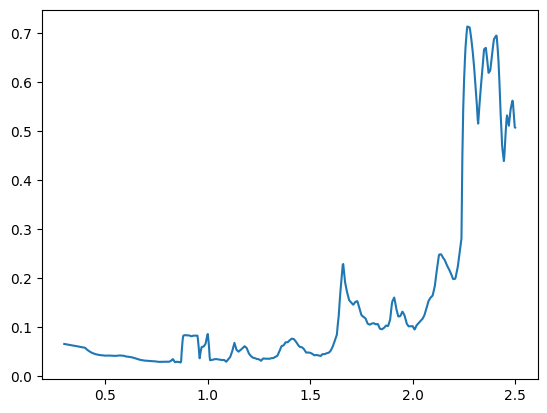

In [15]:
# --- Usando parámetros de Mie ---
f_v = 0.1  # fracción volumétrica (mayor cantidad de aire)

V_p = (4/3) * np.pi * r**3 #volumen de la particula 
rho = f_v / V_p  # densidad volumétrica

# Calcular coeficientes KM
K, S =  calcular_kubelka_munk_coef_abs(rho, C_abs, C_scat, g, n_im,wl)

L_lm=(1/S) #Camino libre medio de transporte

thickness_m=10*L_lm
tickness_n=20*L_lm

idx=np.argmin(np.abs(wl-2.5))
idx2=np.argmin(np.abs(wl-0.3))



# Grosor del material
thickness = 1000.0 #tickness_n # µm
# Calcular la R_dif y T_dif
R_dif, T_dif = get_diffuse_properties(K, S, thickness)
#A_dif=1-R_dif-T_dif
A_dif=1-R_dif
plt.plot(wl,A_dif)


isolar=np.loadtxt('solar.dat')
Iam=np.interp(wl,isolar[:,0]/1000,isolar[:,2])

num=np.trapezoid(R_dif*Iam,wl)
den=np.trapezoid(Iam,wl)

TSR=num/den
print(TSR)



In [16]:
wl_nir=np.linspace(8,13,1000)
n_ren=np.interp(wl_nir,wlx,n_rex)
n_imn=np.interp(wl_nir,wlx,n_imx)
nm = n_ren + 1j * n_imn

n0 = 1.0          # Aire
nt = 1.0       
eps_m = nm**2      # Matriz del material compuesto
eps_i = np.ones(1000) # Rango de permitividad de la inclusión
d_film = thickness      # Espesor en nm

theta_deg = 1*10e-4 # Ángulo de incidencia
theta0 = np.radians(theta_deg)


#for d_vol in deltas_vol:
    # 2. Maxwell Garnett para obtener eps_eff (y n_eff)
eps_eff = eps_m * (
    (2 * f_v * (eps_i - eps_m) + eps_i + 2 * eps_m) /
    (2 * eps_m + eps_i - f_v * (eps_i - eps_m))
    )
n1 = np.sqrt(eps_eff)

0.9488284726021532


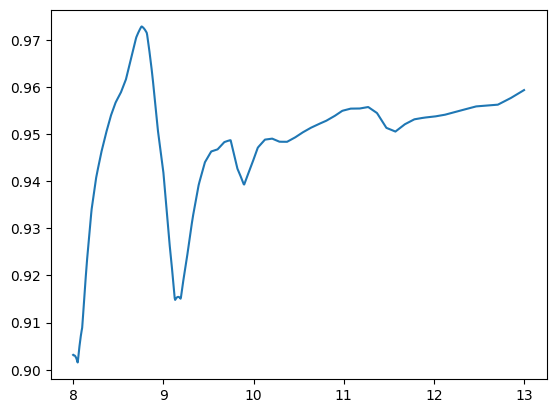

In [17]:
T_ref = 310.0
T_sky = 300.0
h_c=12.0
polarizacion = 'TM' # Se puede cambiar a 'TE'

    # Calcular I_blackbody_lambda DENTRO del bucle para asegurar el broadcasting correcto
I_blackbody_lambda = planck_radiance(wl_nir, T_ref) 
    # --- Tu cálculo de Matriz de Transferencia (TMM) movido aquí ---
    # Asume que n0, n1, nt, theta0, polarizacion están definidos globalmente
    
    # Ángulos internos
sin_thetat = (n0 * np.sin(theta0)) / nt
cos_thetat = np.sqrt(1 - sin_thetat**2 + 0j)
sin_theta1 = (n0 * np.sin(theta0)) / n1
cos_theta1 = np.sqrt(1 - sin_theta1**2 + 0j)
        
    # Admitancias según polarización
if polarizacion == 'TE':
        eta0 = n0 * np.cos(theta0)
        eta1 = n1 * cos_theta1
        etat = nt * cos_thetat
else: # TM
        eta0 = n0 / np.cos(theta0)
        eta1 = n1 / cos_theta1
        etat = nt / cos_thetat

# Fase y Matriz ABCD
phi = (2 * np.pi * n1 * d_film * cos_theta1) / wl_nir # thickness ahora es d_film (L_val[i])
A = np.cos(phi)
B = -1j * np.sin(phi) / eta1
C = -1j * eta1 * np.sin(phi)
D = np.cos(phi)

# Reflectancia y Transmitancia
den = (A * eta0 + B * eta0 * etat + C + D * etat)
num = (A * eta0 + B * eta0 * etat - C - D * etat)


R = np.abs(num / den)**2
T = (4 * eta0 * np.real(etat)) / np.abs(den)**2
    
    # Absortancia espectral (Emisividad espectral)
epsilon_lambda = 1 - R - T
    
    # Promedio ponderado (usando np.trapezoid por compatibilidad futura)
num_avg = np.trapezoid(epsilon_lambda * I_blackbody_lambda, wl_nir)
den_avg = np.trapezoid(I_blackbody_lambda, wl_nir)
Eavg = num_avg / den_avg # Asigna el escalar resultante al array

plt.plot(wl_nir,epsilon_lambda)
print(Eavg)

📌 Todas las soluciones:
Solución 1: -694.994432809559
Solución 2: 309.668982760175
Solución 3: 192.662725024692 - 571.46740578439*I
Solución 4: 192.662725024692 + 571.46740578439*I


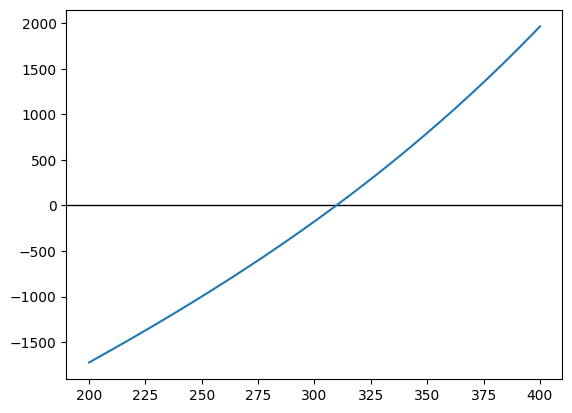

In [18]:
# Definir variables simbólicas
x, E_avg, S, hc, Tsky, Ta, Asol, Is = symbols('x E_avg S hc Tsky Ta Asol Is')

# Definir ecuación simbólica
ecuacion = Eq(E_avg*S*x**4 + hc*x - E_avg*S*Tsky**4 - hc*Ta - Asol*Is, 0)

# Asignar valores numéricos a los parámetros
parametros = {
    E_avg: Eavg,
    S: 5.66961e-8,
    hc: h_c,
    Tsky: T_sky,
    Ta: T_ref,
    Asol: 1-TSR,
    Is: 1000.0
}

# Sustituir valores en la ecuación
ecuacion_num = ecuacion.subs(parametros)

# Resolver
soluciones = solve(ecuacion_num, x)

print("📌 Todas las soluciones:")
for i, r in enumerate(soluciones, 1):
    print(f"Solución {i}: {r.evalf()}")

# Función para graficar
f_np = lambdify(x, ecuacion_num.lhs, 'numpy')

# Rango amplio para no perder raíces
x_vals = np.linspace(200, 400, 1000)
y_vals = f_np(x_vals)

# Graficar
plt.axhline(0, color='black', linewidth=1)
plt.plot(x_vals, y_vals, label='Ecuación')


In [19]:
#Potencia neta

#Potencia solar

Iam15=np.interp(wl*1000,isolar[:,0],isolar[:,2])
Psolar=np.trapezoid(A_dif*Iam15,wl*1000)
print(Psolar)


54.504424343447695


In [20]:
#Potencia radiada
#2) Prad: 2π ∫∫ I_blackbody_lambda(Ts)·ε(λ,θ)·cosθ·sinθ dθ dλ

wl_um = wl_nir              # µm
wl_m  = wl_um * 1e-6        # m
theta = np.linspace(1e-1, np.pi/2 - 1e-1, 150)
#theta = np.linspace(0.17, 1.48, 150)
Ts = 308.914220053661


def TMM_RT(wl_um, theta, n0, n1, nt, d, pol):
    wl = wl_um * 1e-6
    theta0 = theta

    sin_t1 = n0 * np.sin(theta0) / n1
    cos_t1 = np.sqrt(1 - sin_t1**2 + 0j)

    sin_tt = n0 * np.sin(theta0) / nt
    cos_tt = np.sqrt(1 - sin_tt**2 + 0j)

    if pol == 'TE':
        eta0 = n0 * np.cos(theta0)
        eta1 = n1 * cos_t1
        etat = nt * cos_tt
    else:  # TM
        eta0 = n0 / np.cos(theta0)
        eta1 = n1 / cos_t1
        etat = nt / cos_tt

    phi = (2 * np.pi * n1 * d * cos_t1) / wl

    A = np.cos(phi)
    B = -1j * np.sin(phi) / eta1
    C = -1j * eta1 * np.sin(phi)
    D = np.cos(phi)

    den = A * eta0 + B * eta0 * etat + C + D * etat
    num = A * eta0 + B * eta0 * etat - C - D * etat

    R = np.abs(num / den)**2
    T = (4 * eta0 * np.real(etat)) / (np.abs(den)**2)
    return R, T

eps_2D = np.zeros((len(wl_um), len(theta)))

for j, th in enumerate(theta):
    R_TE, T_TE = TMM_RT(wl_um, th, n0, n1, nt, d_film*1e-6, 'TE')
    R_TM, T_TM = TMM_RT(wl_um, th, n0, n1, nt, d_film*1e-6, 'TM')
    #print(T_TE)
    eps_TE = 1 - R_TE  - T_TE
    eps_TM = 1 - R_TM - T_TM

    eps_2D[:, j] = 0.5 * (eps_TE + eps_TM)

    
def Prad_2D(wl_m, theta, eps_2D, Ts):
    """
    Potencia radiada hemisférica espectral-angular
    W/m²
    """
    wl_um = wl_m * 1e6
    B = planck_radiance(wl_um, Ts)   # radiancia

    integrand = (
        eps_2D
        * B[:, None]
        * np.cos(theta)[None, :]
        * np.sin(theta)[None, :]
    )

    return 2 * np.pi * np.trapezoid(
        np.trapezoid(integrand, theta, axis=1),
        wl_m
    )


def Patm_2D(wl_m, theta, eps_2D, Tatm):
    taux = np.genfromtxt("skytrans.dat")
    tau=np.interp(wl_m,taux[:,0]*1e-6,taux[:,1])
    #tau = np.ones_like(wl_m) # la transmitancia de la atmosfera
    #mask = (wl_m*1e6 >= 8) & (wl_m*1e6 <= 13)
    #tau[mask] = 0.8

    eps_atm = 1 - tau[:, None]**(1/np.cos(theta)[None, :])
    B = planck_radiance(wl_m * 1e6, Tatm)

    integrand = eps_2D * eps_atm * B[:, None] * np.cos(theta)[None, :] * np.sin(theta)[None, :]
    
    return 2 * np.pi * np.trapezoid(
        np.trapezoid(integrand, theta, axis=1),
        wl_m
    )

def Pnonrad(Ts, h_c, T_air):
    return h_c * (Ts - T_air)

#print(Prad_2D(wl_m, theta, np.ones_like(eps_2D), 300))
#print(5.67e-8 * 300**4)

def potencias(Ts, T_air, T_sky, Psolar):
    Prad = Prad_2D(wl_m, theta, eps_2D, Ts)
    Patm = Patm_2D(wl_m, theta, eps_2D, T_sky)
    Pnon = Pnonrad(Ts, h_c, T_air)
    
    return {
        "Prad (W/m2)": Prad,
        "Patm (W/m2)": Patm,
        "Psolar (W/m2)": Psolar,
        "Pnonrad (W/m2)": Pnon,
        "Pnet (W/m2)": Prad - Patm - Psolar - Pnon
    }


vals = potencias(Ts, T_ref, T_sky, Psolar)
for k, v in vals.items():
    print(f"{k:15s} = {v:8.2f}")

C:\Users\Jose\AppData\Local\Temp\ipykernel_28668\564644223.py:41: RuntimeWarning: overflow encountered in square
  T = (4 * eta0 * np.real(etat)) / (np.abs(den)**2)


Prad (W/m2)     =   149.89
Patm (W/m2)     =    18.68
Psolar (W/m2)   =    54.50
Pnonrad (W/m2)  =   -13.03
Pnet (W/m2)     =    89.73


In [21]:
12*(310.070775961553-310.0)

0.8493115386361296

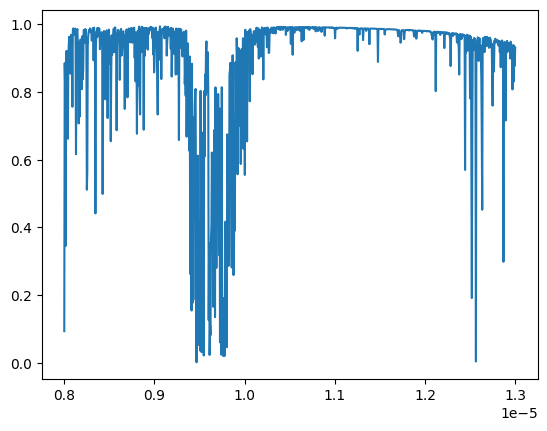

In [22]:
taux = np.genfromtxt("skytrans.dat")
tau=np.interp(wl_m,taux[:,0]*1e-6,taux[:,1])
plt.plot(wl_m,tau)